<a href="https://colab.research.google.com/github/KBCoronado/MachineLearning/blob/main/Unidad4/Practica_1_An%C3%A1lisis_de_Componentes_Principales_(PCA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [17]:
frutas = pd.read_csv("fruit_data_with_colors.csv")
frutas.head()

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79


In [18]:
features = ["mass", "width", "height", "color_score"]
x = frutas[features]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [19]:
#Elegimos dos componentes para visualizacion
pca = PCA(n_components=2)
x_PCA = pca.fit_transform (x_scaled)
#mostrar la porpocion
explained_variance = pca.explained_variance_ratio_
#mostar poporicon de la varianza explicada por cada componente
explained_variance = pca.explained_variance_ratio_
print("Proporcion de varianza explicada por cada componente:", explained_variance)
print("Varianza explicada acumulada", np.cumsum(explained_variance))

Proporcion de varianza explicada por cada componente: [0.57845054 0.25650171]
Varianza explicada acumulada [0.57845054 0.83495225]


In [21]:
#Coeficiente de las variables
componentes = pd.DataFrame(
    pca.components_,
    columns=x.columns,
    index=[f'PC{i+1}' for i in range (pca.n_components)]
)
print("Contribucion de variables a cada componente:")
print(componentes)

Contribucion de variables a cada componente:
         mass     width    height  color_score
PC1  0.626413  0.577999  0.496267    -0.165052
PC2  0.195381  0.254802 -0.238567     0.916509


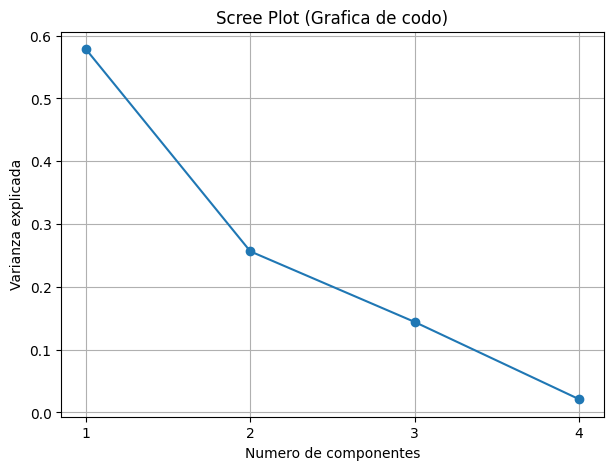

Varianza por componente: [0.57845054 0.25650171 0.14402362 0.02102413]
Varianza acomulada: [0.57845054 0.83495225 0.97897587 1.        ]


In [23]:
pca_full = PCA()
pca_full.fit(x_scaled)
plt.figure(figsize=(7,5))
plt.plot(
    range(1, len(pca_full.explained_variance_ratio_) +1),
    pca_full.explained_variance_ratio_,
    marker="o"
)
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) +1))
plt.xlabel("Numero de componentes")
plt.ylabel("Varianza explicada")
plt.title("Scree Plot (Grafica de codo)")
plt.grid(True)
plt.show()
print("Varianza por componente:", pca_full.explained_variance_ratio_)
print("Varianza acomulada:", pca_full.explained_variance_ratio_.cumsum())


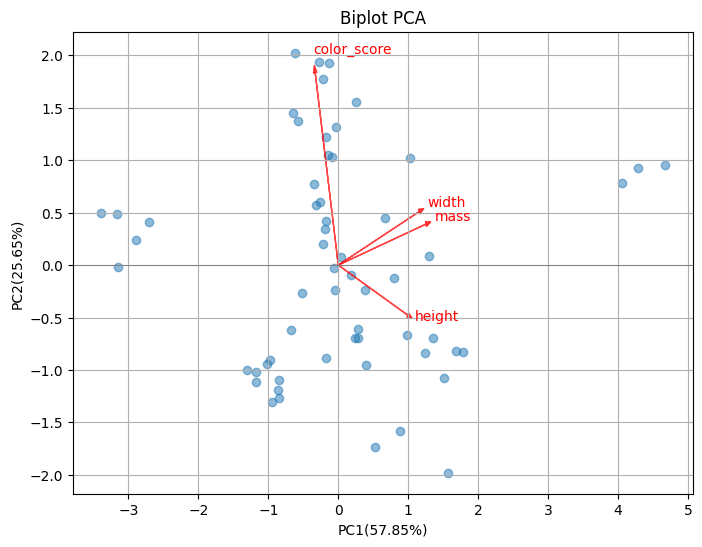

In [25]:
pca = PCA(n_components=2)#definimos el pca con dos componentes
components = pca.fit_transform(x_scaled) #calcular el PCA
loadings = pca.components_.T #loadings vectores
variables = x.columns #guarda los nombres de las variables originales
plt.figure(figsize=(8,6))
plt.scatter(components[:,0], components[:,1], alpha=0.5) #puntos score
#Etiqutas de ejes
plt.xlabel(f"PC1({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2({pca.explained_variance_ratio_[1]*100:.2f}%)")
#Graficar vectores
for i, var in enumerate(variables):
  plt.arrow(0, 0,
            loadings[i, 0]*2,
            loadings[i, 1]*2,
            color="red",
            alpha=0.7,
            head_width=0.05)
  plt.text(loadings[i, 0]*2.2,
           loadings[i,1]*2.2,
           var, color='red')
  plt.title("Biplot PCA")
  plt.grid(True)
  plt.axhline(0, color='gray', lw=0.5)
  plt.axhline(0, color='gray', lw=0.5)
  plt.show